# Behavioural drivers of annual revenue — NovaRetail+

NovaRetail+ is a Latin American ecommerce platform with millions of users. Closing out 2024, the Growth and Retention team needs an answer to one question: **which customer behaviours are most strongly associated with the annual revenue a customer generates?**

This is a correlational study, so it maps associations rather than causes. I say that up front because the strongest number in this analysis is easy to misread as a lever the business can pull, and it is not one.

The work runs in four passes: validate the data, look at the relationships visually, put coefficients on them using the method that matches each pair of variable types, and translate what survives into findings the team can act on.

> **Correlation is not causation.** Every finding below is phrased accordingly.

## 1. Loading and validating the dataset

Before correlating anything I check that the file loads, that the types are right, and that there are no missing values that would quietly distort a coefficient.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency

In [2]:
# Load the dataset.
# The original file lives on the TripleTen platform (/datasets/).
# Outside that platform, fall back to a local data/ folder.
try:
    customer_behaviour = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
except FileNotFoundError:
    customer_behaviour = pd.read_csv('data/novaretail_comportamiento_clientes_2024.csv')

customer_behaviour.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


In [3]:
# First rows, to see the shape of the data
customer_behaviour.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


### Data dictionary

| Column | Meaning |
|---|---|
| `id_cliente` | Unique customer identifier |
| `edad` | Customer age |
| `nivel_ingreso` | Customer's own estimated annual income |
| `visitas_mes` | Visits to the app or site during the month |
| `compras_mes` | Purchases made during the month |
| `gasto_publicidad_dirigida` | Ad spend allocated to that user |
| `satisfaccion` | Satisfaction score, 1 to 5 |
| `miembro_premium` | 1 if the customer holds a premium subscription, 0 otherwise |
| `abandono` | 1 if the customer churned, 0 otherwise |
| `tipo_dispositivo` | Device used: móvil, escritorio or tablet |
| `region` | Region: norte, sur, oeste or este |
| `ingreso_anual` | **Annual revenue the customer generates for the company** |

`ingreso_anual` is the target of the whole analysis. Note that `nivel_ingreso` and `ingreso_anual` sound alike but measure opposite sides of the relationship: what the customer earns, and what the company earns from them.

> Column names stay in Spanish because they come from the source file.

## 2. Data preparation and assumptions

15,000 records, 12 columns, no nulls. The only type that needs fixing is `edad`, which arrives as float even though age here is always a whole number.

In [4]:
# Age is stored as float but holds no decimals; integer is the honest type
customer_behaviour['edad'] = customer_behaviour['edad'].astype(int)
customer_behaviour.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 1.4 MB


### Numeric variables

`edad`, `nivel_ingreso`, `visitas_mes`, `compras_mes`, `gasto_publicidad_dirigida`, `satisfaccion` and `ingreso_anual`.

I exclude `miembro_premium` and `abandono` from this group: pandas reads them as integers, but they are binary flags and their mean would be a proportion, not an average.

In [5]:
# Descriptive statistics, excluding the two binary flags
numeric_vars = (customer_behaviour
                       .select_dtypes(include='number')
                       .drop(columns=['miembro_premium', 'abandono']))
numeric_vars.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**What the distributions show**

- `edad` — mean 38.3 against median 38.0: symmetric, no long tail.
- `nivel_ingreso` — mean and median both near 30,000, CV ≈ 33%: symmetric with moderate spread.
- `visitas_mes` — mean 10.0 against median 10.0: symmetric.
- `compras_mes` — most customers buy once a month, with a tail reaching 8. Standard deviation almost equals the mean (CV ≈ 92%), so the spread is as large as the central value.
- `gasto_publicidad_dirigida` — moderate dispersion, CV ≈ 54%.
- `satisfaccion` — bounded 1 to 5, centred at 3.6.
- `ingreso_anual` — **the 25th percentile is 0**, so at least a quarter of customers generated no revenue at all. That is a whole segment hiding inside the target variable, and I come back to it in Section 5.

### Binary variables

In [6]:
# Confirm each flag really holds only two values
customer_behaviour[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

Both hold exactly two values, coded 0 and 1. No unexpected categories, no cleaning needed.

### Categorical variables

In [7]:
# Unique values per categorical column
categorical_vars = customer_behaviour.select_dtypes(include='object')
print(categorical_vars.nunique())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64


/tmp/ipykernel_515/1037541535.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = customer_behaviour.select_dtypes(include='object')


In [8]:
# How the two real categoricals are distributed
print(customer_behaviour['tipo_dispositivo'].value_counts(normalize=True).round(4))
print()
print(customer_behaviour['region'].value_counts())

tipo_dispositivo
móvil         0.6545
escritorio    0.2480
tablet        0.0975
Name: proportion, dtype: float64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


`id_cliente` has 15,000 unique values on 15,000 rows — one per customer, so it is an identifier rather than a category, and it carries no analytical information.

- `tipo_dispositivo` — móvil dominates at 65.5%, escritorio 24.8%, tablet 9.7%.
- `region` — norte leads with 4,395 customers and este trails with 3,069. No region is small enough to make its subgroup unreliable.

### Assumptions

- The analysis uses the full dataset; no sampling.
- The data carries no recording errors and is correctly typed after the `edad` fix.
- The coefficient is chosen by variable type, never by which one returns a larger number:
  - **Pearson** — linear relationship between two numeric variables.
  - **Spearman** — monotonic relationship; does not assume normality. Reporting it beside Pearson shows whether a relationship holds when only rank order matters.
  - **Point-biserial** — numeric against binary.
  - **Cramér's V** — association between two categorical variables.

**Core assumption:** this analysis identifies relationships between variables and segments. It does not establish causation.

## 3. Visualising relationships

I look at the shape of the relationships before putting numbers on them. A coefficient collapses a cloud of 15,000 points into a single digit, and that digit hides outliers, curvature and clusters.

### Correlation heatmap

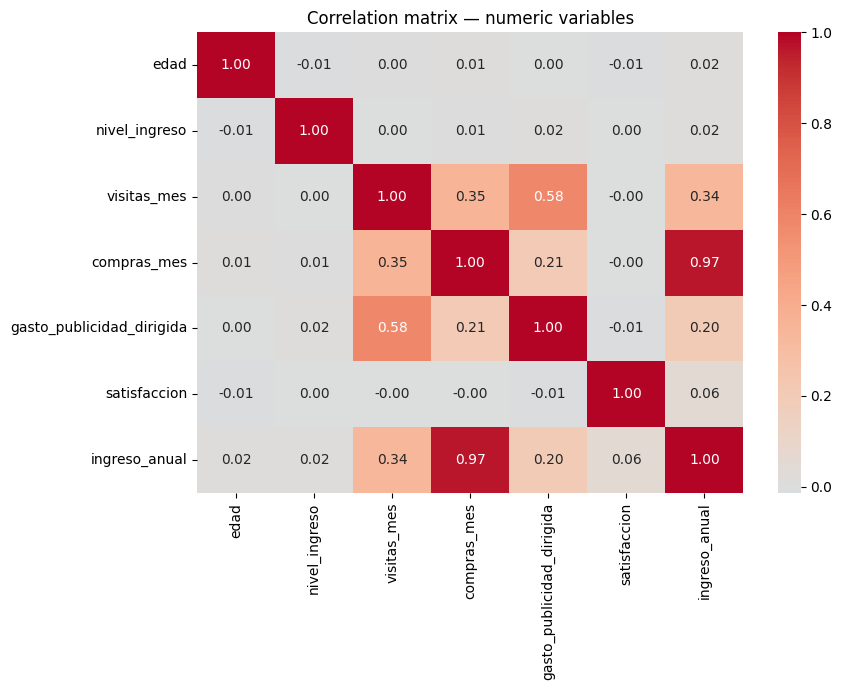

In [9]:
corr_matrix = numeric_vars.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix — numeric variables')
plt.tight_layout()
plt.show()

**What the matrix shows**

- `compras_mes` and `ingreso_anual` sit at **0.97** — the strongest value in the matrix by a wide margin, and far past the 0.85 threshold at which two variables stop carrying independent information.
- `ingreso_anual` against `visitas_mes` is **0.34**: moderate, and the only other relationship with the target worth examining.
- `gasto_publicidad_dirigida` and `visitas_mes` reach **0.58**, but neither of them is the target variable; this is a relationship between two inputs.
- `edad`, `nivel_ingreso` and `satisfaccion` sit near zero against everything, including revenue. Nothing about who the customer is predicts what they spend — only what they do.

### Why there is no general scatterplot

A full pairplot would draw 21 panels, and the heatmap already shows that most of those pairs sit near zero. Plotting them would add visual noise without adding information, so I go straight to the two pairs that involve the target variable.

### Scatterplots for the key pairs

Both pairs are plotted against `ingreso_anual`, since that is the variable the business question is about.

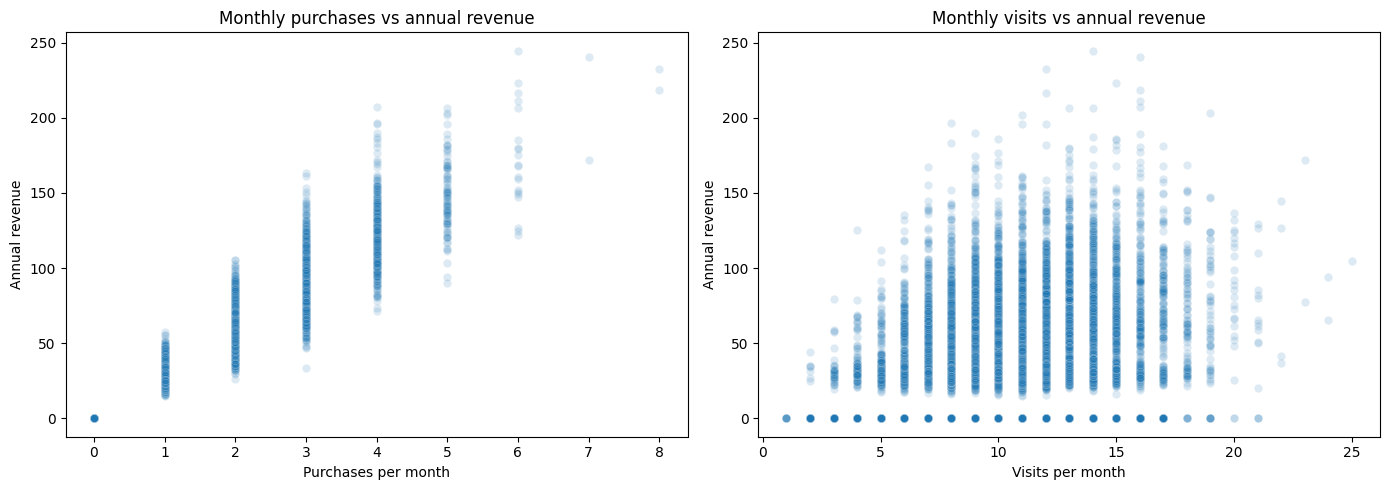

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# alpha is essential here: with 15,000 points a plain scatter becomes a solid
# block and the density of the cloud is impossible to read
sns.scatterplot(data=customer_behaviour, x='compras_mes', y='ingreso_anual',
                alpha=0.15, ax=axes[0])
axes[0].set_title('Monthly purchases vs annual revenue')
axes[0].set_xlabel('Purchases per month')
axes[0].set_ylabel('Annual revenue')

sns.scatterplot(data=customer_behaviour, x='visitas_mes', y='ingreso_anual',
                alpha=0.15, ax=axes[1])
axes[1].set_title('Monthly visits vs annual revenue')
axes[1].set_xlabel('Visits per month')
axes[1].set_ylabel('Annual revenue')

plt.tight_layout()
plt.show()

**What the scatterplots show**

**`compras_mes` vs `ingreso_anual`** — positive, tight and close to linear. The points stack into vertical bands because purchases are discrete, and each band sits higher than the last. The band at zero purchases sits flat on zero revenue, with no spread at all: nobody with zero purchases generated any revenue. That detail turns out to matter, and I take it up in Finding 3.

**`visitas_mes` vs `ingreso_anual`** — positive but much more diffuse. For any given number of visits, revenue ranges from zero to the top of the scale. Visits move with revenue, but weakly enough that visits alone tell you very little about what a customer will be worth.

## 4. Correlation coefficients

Numbers to back the patterns, one method per variable-type pairing.

### Pearson and Spearman — numeric against numeric

Both pairs are measured against `ingreso_anual`. Reporting Pearson and Spearman side by side is a check in itself: when they agree, the relationship is stable whether measured by magnitude or by rank.

In [11]:
pairs = [('compras_mes', 'ingreso_anual'),
         ('visitas_mes', 'ingreso_anual')]

for a, b in pairs:
    pearson  = customer_behaviour[a].corr(customer_behaviour[b], method='pearson')
    spearman = customer_behaviour[a].corr(customer_behaviour[b], method='spearman')
    print(f'{a} vs {b}:  Pearson {pearson:.4f}  |  Spearman {spearman:.4f}')

compras_mes vs ingreso_anual:  Pearson 0.9671  |  Spearman 0.9675
visitas_mes vs ingreso_anual:  Pearson 0.3371  |  Spearman 0.3210


**Reading the coefficients**

**`compras_mes` vs `ingreso_anual` — 0.967 / 0.967.** Extremely strong and positive, and identical under both methods. Past the 0.85 threshold this stops being a finding about customer behaviour and becomes a warning about the data: the two columns carry nearly the same information.

**`visitas_mes` vs `ingreso_anual` — 0.337 / 0.321.** Moderate and positive. Pearson slightly above Spearman means a few high-visit, high-revenue customers pull the linear measure up; the rank-based measure is the more conservative read.

### Point-biserial — numeric against binary

Point-biserial is the right coefficient when one variable is a 0/1 flag and the other is continuous. Running Pearson here would give the same number, but naming the method correctly documents that the binary nature of the variable was considered rather than overlooked.

In [12]:
for flag in ['miembro_premium', 'abandono']:
    r, p = pointbiserialr(customer_behaviour[flag],
                          customer_behaviour['ingreso_anual'])
    print(f'{flag} vs ingreso_anual:  r = {r:.4f}  |  p = {p:.3g}')

miembro_premium vs ingreso_anual:  r = 0.0931  |  p = 3.09e-30
abandono vs ingreso_anual:  r = -0.0028  |  p = 0.729


**`miembro_premium` vs `ingreso_anual` — r = 0.093.** Positive but very weak. The p-value is tiny (3e-30), which with n = 15,000 says the association is real, not that it is large. Premium members do generate slightly more revenue, but the effect is too small to justify treating premium status as a revenue driver.

This is the clearest example in the analysis of why statistical significance and business relevance are different questions.

**`abandono` vs `ingreso_anual` — r = -0.003, p = 0.73.** Effectively zero, and not significant. Revenue tells you nothing about whether a customer churned: high-value customers leave at about the same rate as low-value ones. If the team wants to understand churn, revenue is the wrong place to look.

### Cramér's V — categorical against categorical

Cramér's V rescales the chi-square statistic to a 0-to-1 range so associations between categorical variables can be compared on a common scale. A binary flag is a categorical variable with two levels, so `abandono` and `miembro_premium` belong here too.

In [13]:
def cramers_v(var1, var2):
    """Cramér's V: chi-square normalised to a 0-1 scale."""
    table = pd.crosstab(customer_behaviour[var1], customer_behaviour[var2])
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    min_dim = min(table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

In [14]:
category_pairs = [('abandono', 'tipo_dispositivo'),
          ('abandono', 'region'),
          ('abandono', 'miembro_premium'),
          ('tipo_dispositivo', 'region')]

for a, b in category_pairs:
    print(f'{a:18s} vs {b:18s}  V = {cramers_v(a, b):.4f}')

abandono           vs tipo_dispositivo    V = 0.0072
abandono           vs region              V = 0.0154
abandono           vs miembro_premium     V = 0.1202
tipo_dispositivo   vs region              V = 0.0124


**Reading the four associations**

- **`abandono` vs `tipo_dispositivo` — 0.007.** No association. Churn does not depend on the device the customer uses.
- **`abandono` vs `region` — 0.015.** No association. Churn is not concentrated in any region.
- **`abandono` vs `miembro_premium` — 0.120.** The strongest of the four, though still weak. Premium status carries slightly more information about churn than geography or device do — the only lead in the churn direction this dataset offers.
- **`tipo_dispositivo` vs `region` — 0.012.** No association. Device preference is the same across all four regions, so device and region can be treated as independent dimensions in any segmentation.

Three of the four are effectively zero. Read together, they say something useful: churn in this dataset is not explained by who the customer is or where they are, which means the answer lies in behavioural variables this analysis has not covered.

## 5. Business findings

Each finding states the visual evidence, the numeric evidence, what can be read from it, what cannot, and what the business should do about it.

### Finding 1 — Purchases and revenue are the same signal

**Visual evidence:** the scatterplot of `compras_mes` against `ingreso_anual` in Section 3 — a tight, almost linear positive cloud.

**Numeric evidence:** Pearson 0.967, Spearman 0.967. The highest value in the matrix, far above the 0.85 collinearity threshold.

**Interpretation:** monthly purchases and annual revenue move almost in lockstep. They are not two behaviours that happen to be related; they are close to two measurements of the same thing.

**What cannot be claimed:** that purchases *cause* revenue in any actionable sense. A coefficient this high between a count of purchases and the money those purchases generate is close to a definitional relationship, not a discovered one.

**Business implication:** do not treat these as two independent signals. Any model, dashboard or segmentation that uses both is double-counting the same information. One of them is enough, and `ingreso_anual` is the one the business cares about.

### Finding 2 — Visits move with revenue, but weakly

**Visual evidence:** the scatterplot of `visitas_mes` against `ingreso_anual` — positive but widely dispersed, with revenue spanning the full range at every visit count.

**Numeric evidence:** Pearson 0.337, Spearman 0.321.

**Interpretation:** after purchases, visit frequency is the behaviour most associated with revenue. But a coefficient of 0.34 means the relationship explains only a small share of the variation: plenty of frequent visitors generate nothing, and some infrequent ones generate a lot.

**What cannot be claimed:** that driving more visits produces more revenue. The relationship could run the other way — customers who intend to buy visit more often — or be driven by a third factor such as general engagement with the category.

**Business implication:** visits are worth tracking as a leading indicator, not as a target to maximise on their own. Note also that `gasto_publicidad_dirigida` correlates with `visitas_mes` at 0.58, considerably more than visits correlate with revenue. There is a plausible chain from ad spend to visits to revenue, but it weakens at each step, and the only way to know whether it holds is an experiment: raise spend for a randomly assigned segment and measure the effect on visits *and* on revenue.

### Finding 3 — The zero-revenue segment is not a data problem

The descriptive statistics showed that the 25th percentile of `ingreso_anual` is 0. That looked like a data quality issue worth flagging. It is not — and the check takes one line.

In [15]:
zero_revenue = customer_behaviour['ingreso_anual'] == 0
zero_purchases = customer_behaviour['compras_mes'] == 0

print(f'Customers with zero revenue  : {zero_revenue.sum():,} ({zero_revenue.mean():.1%})')
print(f'Customers with zero purchases: {zero_purchases.sum():,}')
print(f'Are they the same customers? {(zero_revenue == zero_purchases).all()}')

Customers with zero revenue  : 4,567 (30.4%)
Customers with zero purchases: 4,567
Are they the same customers? True


In [16]:
# How much of the 0.97 correlation comes from that block of paired zeros?
buyers = customer_behaviour[customer_behaviour['compras_mes'] > 0]

corr_with_non_buyers = customer_behaviour['compras_mes'].corr(customer_behaviour['ingreso_anual'])
corr_buyers_only = buyers['compras_mes'].corr(buyers['ingreso_anual'])

print(f'Pearson including non-buyers: {corr_with_non_buyers:.4f}')
print(f'Pearson among buyers only   : {corr_buyers_only:.4f}')

Pearson including non-buyers: 0.9671
Pearson among buyers only   : 0.9341


**Numeric evidence:** 4,567 customers (30.4% of the base) generated zero revenue, and they are *exactly* the 4,567 customers who made zero purchases — the two sets match perfectly.

**Interpretation:** there is no missing data and no recording error. Revenue is zero because no purchase happened. Almost a third of the customer base visited the platform during the period and bought nothing.

This also explains part of Finding 1. Excluding non-buyers, the correlation between purchases and revenue falls from 0.967 to 0.934 — still very high, but the paired block of zeros was inflating it. A coefficient computed over a population containing a large, perfectly aligned zero segment reports partly on the existence of that segment rather than on the relationship among the rest.

**What cannot be claimed:** anything about *why* they did not buy. The dataset records the outcome, not the reason.

**Business implication:** the largest revenue opportunity in this dataset is not making buyers buy more — it is that 30% of the base buys nothing at all. That segment deserves its own analysis, and it is the natural next question after this one.

## 6. Limitations and next steps

### Limitations

- **Correlation is not causation.** Every relationship reported here is an association measured in 2024 data. None of them establishes that changing one variable would move another.
- **Exploratory, not predictive.** This maps relationships that exist in the data; it does not build or validate a model that forecasts customer behaviour.
- **Collinearity between `compras_mes` and `ingreso_anual`.** At 0.967 they carry nearly identical information, and treating them as independent signals would be a methodological error.
- **The zero-revenue segment shapes the results.** 30.4% of customers generated no revenue, and that block affects every coefficient computed over the full base — as Finding 3 demonstrates for the strongest pair.
- **Customer attributes were not examined in depth.** `edad`, `nivel_ingreso` and `satisfaccion` sit near zero against revenue in the aggregate, but an aggregate near zero can hide opposing effects between subgroups. That would need segmented analysis to rule out.

### Next steps

1. **Analyse the non-buyer segment separately.** Compare the 4,567 non-buyers against buyers on visits, ad spend, satisfaction and device. Converting a fraction of a third of the customer base is worth more than optimising the customers already buying.
2. **Test the advertising chain experimentally.** Ad spend correlates with visits at 0.58 and visits with revenue at 0.34. Only a randomised test — raising spend for one segment and measuring both visits and revenue — can tell whether the chain holds end to end.
3. **Look for churn drivers outside revenue.** Revenue (r = -0.003), device (V = 0.007) and region (V = 0.015) say nothing about churn. Premium status (V = 0.120) is the only weak lead. The explanation likely lies in variables not present here: support contacts, time since last purchase, in-session behaviour.
4. **Re-run the correlations within segments.** Repeating this analysis separately for buyers, for premium members and by region would reveal whether the aggregate coefficients hold or whether they average out opposing patterns.